In [2]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt

I0000 00:00:1790673690.445907    8385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790673690.448696    8385 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790673690.848194    8385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790673692.060471    8385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [3]:
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print(x_train.shape)
print(y_train.shape)
print(y_train[0:12])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
[5 0 4 1 9 2 1 3 1 4 3 5]


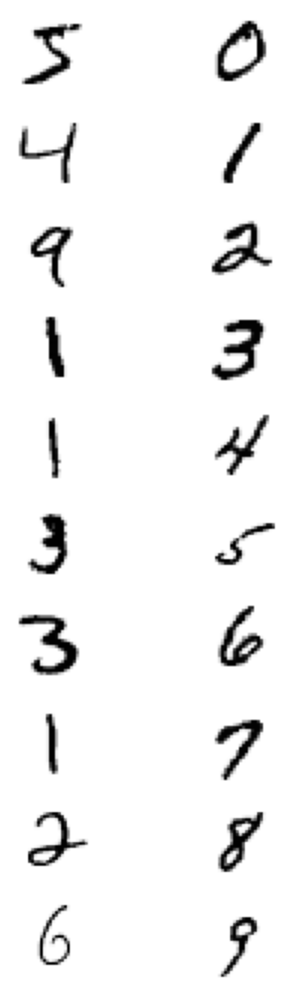

In [4]:
plt.figure(figsize=(5, 10))

for k in range(20):
    plt.subplot(10, 2, k + 1)
    plt.imshow(x_train[k], cmap="Greys")
    plt.axis("off")

plt.tight_layout()
plt.show()

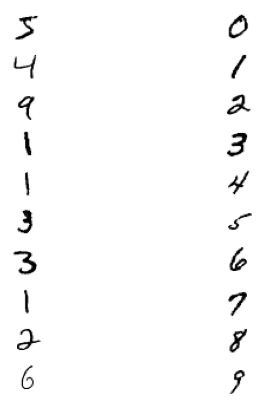

In [5]:
plt.figure(figsize=(5, 5))

for k in range(20):
    plt.subplot(10, 2, k + 1)
    plt.imshow(x_train[k], cmap='Greys')
    plt.axis('off')

plt.show()

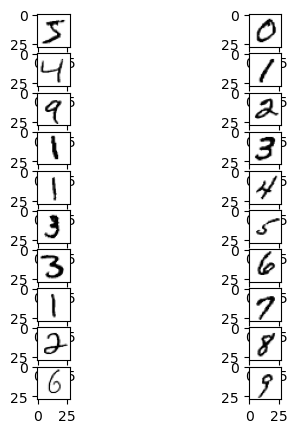

In [6]:
plt.figure(figsize=(5, 5))

for k in range(20):
    plt.subplot(10, 2, k + 1)
    plt.imshow(x_train[k], cmap='Greys')
    plt.axis('on')

plt.show()

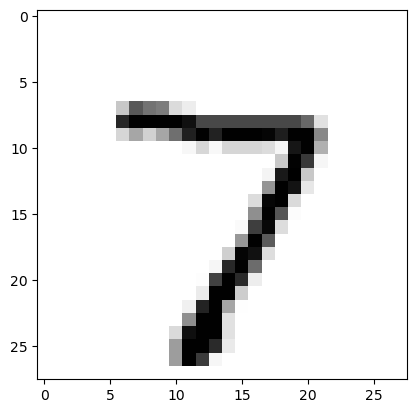

In [7]:
plt.imshow(x_valid[0], cmap='Greys')
plt.show()

In [8]:
print(y_valid.shape)
print(x_valid[0])

(10000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 1

In [9]:
print(y_valid[0])

7


In [10]:
x_train = x_train.reshape(60000, 784).astype('float32')
x_valid = x_valid.reshape(10000, 784).astype('float32')

x_train /= 255
x_valid /= 255

In [11]:
from tensorflow.keras.utils import to_categorical

n_classes = 10

y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_valid, n_classes)

print(y_valid[0])
print(y_train[0])
print(x_valid[0])

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.    

In [12]:
print(x_train[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [13]:
print(x_valid[3])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [14]:
print(y_valid[3])

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
model = Sequential()

# Hidden layer
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))

# Output layer
model.add(Dense(10, activation='softmax'))

# Model summary
model.summary()

/home/kmea/.local/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790674107.461791    8385 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print(64 * 784)              # Weights in hidden layer
print((64 * 784) + 64)       # Weights + biases in hidden layer

print(10 * 64)               # Weights in output layer
print((10 * 64) + 10)        # Weights + biases in output layer

print(((10 * 64) + 10) + ((64 * 784) + 64))  

50176
50240
640
650
50890


In [17]:
model.compile(
    loss='mean_squared_error',
    optimizer=SGD(learning_rate=0.03),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=75,
    verbose=1
)


Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1134 - loss: 0.0921
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - accuracy: 0.1791 - loss: 0.0899
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2556 - loss: 0.0886  
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2779 - loss: 0.0874
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.3063 - loss: 0.0863
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3577 - loss: 0.0853
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.3988 - loss: 0.0842
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.4178 - loss: 0.0830
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.4303 - loss: 0.0818
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4391 - loss: 0.0806
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.4502 - loss: 0.0793
Epoch 12/75
469/469 ━━━━━━━━━━━━━━━━━━

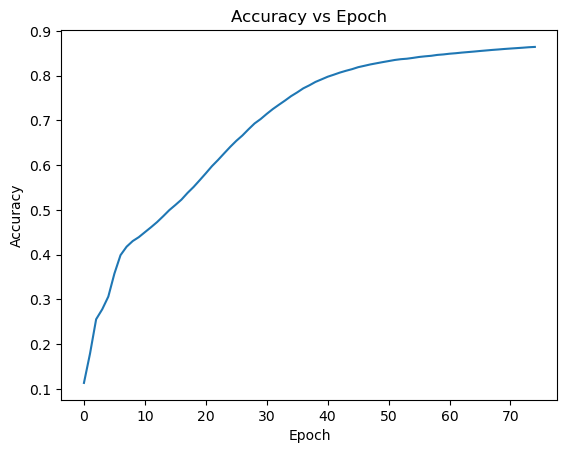

In [19]:
plt.plot(history.history['accuracy'])
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

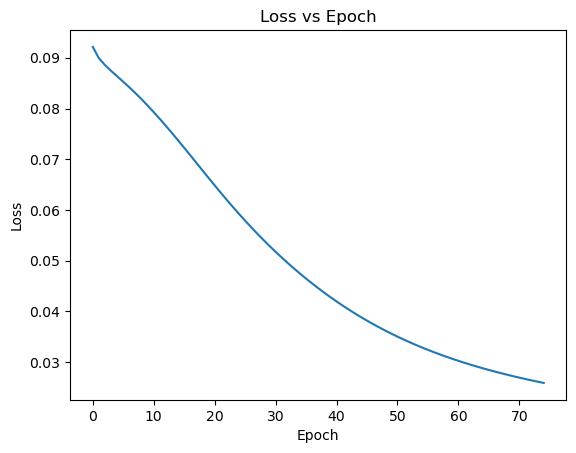

In [20]:
plt.plot(history.history['loss'])
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()